# RoBERTa Baseline

Just throw the original data into roberta and pray.


In [1]:
!pip install python-dotenv huggingface_hub

In [2]:
import os
import re
import random

import numpy as np
import pandas as pd
import torch

from sklearn.metrics import (
    f1_score,
    precision_score,
    recall_score,
    classification_report,
    confusion_matrix,
)

import matplotlib.pyplot as plt
import seaborn as sns
import contractions

from dotenv import load_dotenv
from huggingface_hub import login

from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    Trainer,
    TrainingArguments,
    set_seed,
)

SEED = 42
set_seed(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')


/home/wowthecoder/imperial-nlp-cw/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda


In [3]:
def load_task1(tsv_path: str) -> pd.DataFrame:
    """Load labelled PCL dataset; binarise labels (0/1 -> 0, 2/3/4 -> 1)."""
    rows = []
    with open(tsv_path, encoding='utf-8') as f:
        for line in f.readlines()[4:]:
            parts = line.rstrip('\n').split('\t')
            if len(parts) < 6:
                continue
            orig_label = parts[-1]
            rows.append({
                'par_id':  str(parts[0]),
                'art_id':  parts[1],
                'keyword': parts[2],
                'country': parts[3],
                'text':    parts[4],
                'label':   0 if orig_label in {'0', '1'} else 1,
            })
    return pd.DataFrame(rows)

In [4]:
# Local auth: load Hugging Face token from .env
load_dotenv()
hf_token = os.getenv('HF_TOKEN')
if hf_token:
    login(token=hf_token)
    print('HF token loaded from .env and login completed.')
else:
    print('HF_TOKEN not found in .env; proceeding without explicit login.')


Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


HF token loaded from .env and login completed.


In [5]:
# ============================================================
# Configuration
# ============================================================
MODEL_NAME = 'roberta-base'
RUN_NAME = 'checkpoints/baseline'
MAX_LENGTH = 256

DATA_ROOT='..'
TSV_PATH       = os.path.join(DATA_ROOT, 'dontpatronizeme_pcl.tsv')
TRAIN_IDS_PATH = os.path.join(DATA_ROOT, 'train', 'train_semeval_parids-labels.csv')
DEV_IDS_PATH = os.path.join(DATA_ROOT, 'train', 'dev_semeval_parids-labels.csv')
TEST_PATH = os.path.join(DATA_ROOT, 'test', 'task4_test.tsv')

os.makedirs(RUN_NAME, exist_ok=True)

print(f'RUN_NAME  : {RUN_NAME}')


RUN_NAME  : checkpoints/baseline


In [6]:
# ============================================================
# Load + preprocess data (local module)
# ============================================================
df = load_task1(TSV_PATH)

print(f'Loaded dataset: {len(df):,} samples')
print(df['label'].value_counts().sort_index().rename({0: 'No-PCL', 1: 'PCL'}))



Loaded dataset: 10,469 samples
label
No-PCL    9476
PCL        993
Name: count, dtype: int64


In [7]:
# ============================================================
# Official Train/Dev split
# ============================================================
train_ids_df = pd.read_csv(TRAIN_IDS_PATH, dtype={'par_id': str})
dev_ids_df = pd.read_csv(DEV_IDS_PATH, dtype={'par_id': str})

train_par_ids = set(train_ids_df['par_id'].astype(str))
dev_par_ids = set(dev_ids_df['par_id'].astype(str))

train_df = df[df['par_id'].isin(train_par_ids)].copy().reset_index(drop=True)
dev_df = df[df['par_id'].isin(dev_par_ids)].copy().reset_index(drop=True)


In [8]:
# ============================================================
# Tokenization + Hugging Face Datasets
# ============================================================
train_hf = Dataset.from_pandas(train_df, preserve_index=False)
dev_hf = Dataset.from_pandas(dev_df, preserve_index=False)

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)


def tokenize(batch):
    return tokenizer(batch['text'], truncation=True, max_length=MAX_LENGTH)


train_ds = train_hf.map(tokenize, batched=True, remove_columns=['text'])
dev_ds = dev_hf.map(tokenize, batched=True, remove_columns=['text'])

train_ds = train_ds.rename_column('label', 'labels')
dev_ds = dev_ds.rename_column('label', 'labels')

train_ds.set_format(type='torch', columns=['input_ids', 'attention_mask', 'labels'])
dev_ds.set_format(type='torch', columns=['input_ids', 'attention_mask', 'labels'])

# data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

print(train_ds)
print(dev_ds)



Map: 100%|██████████| 2094/2094 [00:00<00:00, 6666.13 examples/s]

Dataset({
    features: ['par_id', 'art_id', 'keyword', 'country', 'labels', 'input_ids', 'attention_mask'],
    num_rows: 8375
})
Dataset({
    features: ['par_id', 'art_id', 'keyword', 'country', 'labels', 'input_ids', 'attention_mask'],
    num_rows: 2094
})


In [9]:
# ============================================================
# Metrics (F1 on the PCL positive class)
# ============================================================
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)

    return {
        "f1_pcl": f1_score(labels, preds, average="binary", pos_label=1, zero_division=0),
        "precision_pcl": precision_score(labels, preds, average="binary", pos_label=1, zero_division=0),
        "recall_pcl": recall_score(labels, preds, average="binary", pos_label=1, zero_division=0),
    }


In [12]:
# ============================================================
# Model + TrainingArguments + Trainer
# ============================================================
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,
)

# Same core training setup as the example notebook, with batch size=4.
training_args = TrainingArguments(
    RUN_NAME,
    num_train_epochs=2,
    save_total_limit=2,
    learning_rate=1e-5,
    eval_strategy='epoch',
    save_strategy='epoch',
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    metric_for_best_model="f1_pcl",
    greater_is_better=True,
    load_best_model_at_end=True,
    report_to='none',
    seed=SEED,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=dev_ds,
    processing_class=tokenizer,
    # data_collator=data_collator,
    compute_metrics=compute_metrics,
)

print('Trainer configured.')


Loading weights: 100%|██████████| 197/197 [00:00<00:00, 446.69it/s, Materializing param=roberta.encoder.layer.11.output.dense.weight]              
RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Conside

Trainer configured.


In [13]:
train_result = trainer.train()
train_result


Epoch,Training Loss,Validation Loss,F1 Pcl,Precision Pcl,Recall Pcl
1,0.349993,0.263066,0.544529,0.551546,0.537688
2,0.252004,0.336864,0.534884,0.634483,0.462312


Writing model shards: 100%|██████████| 1/1 [00:01<00:00,  1.89s/it]
There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.la

TrainOutput(global_step=4188, training_loss=0.31584370238733156, metrics={'train_runtime': 284.9529, 'train_samples_per_second': 58.782, 'train_steps_per_second': 14.697, 'total_flos': 763726088172600.0, 'train_loss': 0.31584370238733156, 'epoch': 2.0})

In [14]:
eval_metrics = trainer.evaluate()
print('Evaluation metrics:')
for k, v in eval_metrics.items():
    if isinstance(v, (int, float)):
        print(f'  {k}: {v:.4f}')
    else:
        print(f'  {k}: {v}')


Evaluation metrics:
  eval_loss: 0.2633
  eval_f1_pcl: 0.5496
  eval_precision_pcl: 0.5567
  eval_recall_pcl: 0.5427
  eval_runtime: 6.4095
  eval_samples_per_second: 326.7030
  eval_steps_per_second: 81.7540
  epoch: 2.0000


              precision    recall  f1-score   support

      No-PCL     0.9521    0.9546    0.9534      1895
         PCL     0.5567    0.5427    0.5496       199

    accuracy                         0.9155      2094
   macro avg     0.7544    0.7487    0.7515      2094
weighted avg     0.9145    0.9155    0.9150      2094



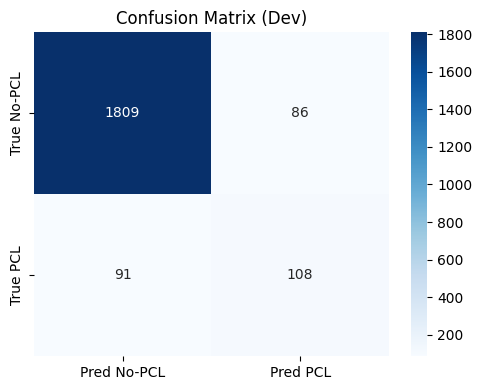

In [15]:
# ============================================================
# Detailed evaluation report
# ============================================================
pred_output = trainer.predict(dev_ds)
logits = pred_output.predictions
y_true = pred_output.label_ids
y_pred = np.argmax(logits, axis=-1)

print(classification_report(y_true, y_pred, target_names=['No-PCL', 'PCL'], digits=4, zero_division=0))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Pred No-PCL', 'Pred PCL'],
    yticklabels=['True No-PCL', 'True PCL'],
)
plt.title('Confusion Matrix (Dev)')
plt.tight_layout()
plt.savefig(os.path.join(RUN_NAME, 'confusion_matrix.png'), dpi=300)
plt.show()


In [16]:
BEST_MODEL_DIR = os.path.join(RUN_NAME, 'best')
trainer.save_model(BEST_MODEL_DIR)
tokenizer.save_pretrained(BEST_MODEL_DIR)
print(f'Saved best model and tokenizer to: {BEST_MODEL_DIR}')


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards: 100%|██████████| 1/1 [00:01<00:00,  1.86s/it]

Saved best model and tokenizer to: checkpoints/baseline/best
